In [44]:
# Aftershock v1 Forecasting how much the S&P 500 (through the SPY fund) will move over the next 5 trading days.


In [23]:
# --- Load every tool (library) the project needs ---
import pandas as pd              # tables of data (like Excel inside Python)
import numpy as np               # fast math on lists of numbers
import matplotlib.pyplot as plt  # drawing charts
import sklearn                   # scikit-learn: classic machine learning tools
import lightgbm                  # LightGBM: our machine learning challenger
import yfinance as yf            # downloads prices from Yahoo Finance

# --- Print each tool's name and version, one per line ---
# Each library stores its own version number in __version__
for lib in [pd, np, sklearn, lightgbm, yf]:
    print(lib.__name__, lib.__version__)  # e.g. "pandas 2.2.2"

pandas 2.2.3
numpy 2.1.3
sklearn 1.6.1
lightgbm 4.6.0
yfinance 0.2.66


## 1. Get the data

In [24]:
# Ask Yahoo Finance for SPY's daily prices, from its first day until today
# auto_adjust=True folds dividends into the price (explained below)
# progress=False hides the download progress bar
raw = yf.download("SPY", start="1993-01-29", auto_adjust=True, progress=False)

# raw has several columns (Open, High, Low, Close, Volume). We only need Close.
# .squeeze() turns the one-column table into a simple list of prices with dates
# .dropna() removes any day that has a missing price
prices = raw["Close"].squeeze().dropna()

# Give the list a clear name, which will be the column name later
prices.name = "price"

# Look at the first 5 and last 5 rows to check the dates make sense
print(prices.head())
print(prices.tail())

# Count how many trading days we got
print("Rows:", len(prices))

Date
1993-01-29    24.053528
1993-02-01    24.224607
1993-02-02    24.275917
1993-02-03    24.532547
1993-02-04    24.635178
Name: price, dtype: float64
Date
2026-10-01    763.989990
2026-10-02    769.640015
2026-10-05    774.830017
2026-10-06    779.090027
2026-10-07    777.219971
Name: price, dtype: float64
Rows: 8480


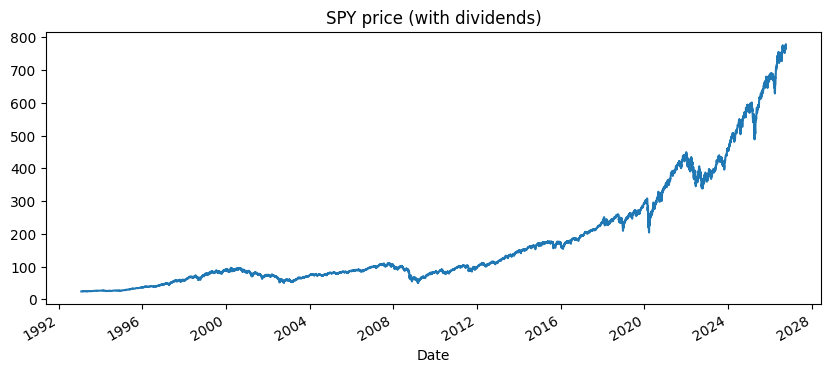

In [25]:
# Plot the price over time so we can see the history with our own eyes
prices.plot(title="SPY price (with dividends)", figsize=(10, 4))  # figsize = width, height in inches
plt.show()  # display the chart

 2. Returns and target

In [26]:
# H is the "horizon": how many trading days ahead we want to forecast
H = 5

# Put the prices into a DataFrame (a table) so we can add more columns to it
df = pd.DataFrame({"price": prices})

# Log return: ln(today's price / yesterday's price)
# .shift(1) slides the column down one row, so each row sees yesterday's price
df["r"] = np.log(df["price"] / df["price"].shift(1))

# Squared return: makes up and down moves both positive (this is the raw material of volatility)
df["r2"] = df["r"] ** 2

In [27]:
# Add up the squared returns of the NEXT 5 days, for every day t
# rolling(H).sum() on day t+5 adds up days t+1 to t+5 (a "window" of 5 days looking backward)
# shift(-H) then slides the answer UP 5 rows, so it lands on day t
future_sum = df["r2"].rolling(H).sum().shift(-H)

# Convert to yearly volatility:
# 252 / H scales 5 days up to a full year, and sqrt turns "squared" back into normal size
df["target_vol"] = np.sqrt(252 / H * future_sum)

# The models will guess the LOG of volatility, because logs make the big spikes less extreme
# and make the numbers more stable and easier to learn from
df["target"] = np.log(df["target_vol"])

In [28]:
# Pick any row number to test (row 100 is fine)
i = 100

# Do the same calculation manually using only the 5 days after row i
# iloc[i+1 : i+1+H] selects the rows i+1, i+2, i+3, i+4, i+5
by_hand = np.sqrt(252 / H * sum(df["r"].iloc[i+1:i+1+H] ** 2))

# Compare the manual answer with the one our formula computed. They must match.
print(by_hand, df["target_vol"].iloc[i])

0.12801032005918092 0.12801032005918098


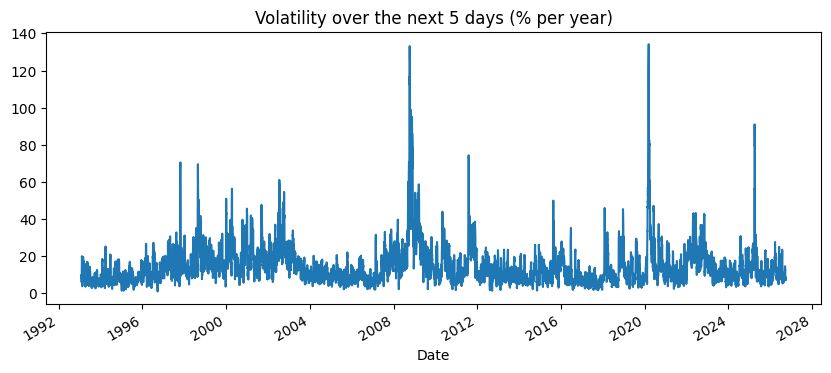

Average: 15.0 %


In [29]:
# Multiply by 100 to show it as a percentage, then draw it
(df["target_vol"] * 100).plot(title="Volatility over the next 5 days (% per year)", figsize=(10, 4))
plt.show()

# The average volatility over the whole history, as a percentage
print("Average:", round(df["target_vol"].mean() * 100, 1), "%")

3. Inputs

In [30]:
# Helper function: volatility over the LAST n days, including today
# rolling(n).sum() looks BACKWARD (today and the n-1 days before it), so there is no peeking
# 252 / n scales it to a yearly figure, sqrt turns "squared" back to normal size
def past_vol(n):
    return np.sqrt(252 / n * df["r2"].rolling(n).sum())

# A few days have a return of exactly 0, and log(0) is not allowed
# So we set a tiny floor: any value below 0.0001 is raised to 0.0001
TINY = 1e-4

# Build the three volatility inputs, in log form (same as the target, so they are comparable)
# .clip(lower=TINY) applies the floor before taking the log
df["vol_1d"] = np.log(past_vol(1).clip(lower=TINY))    # last 1 day
df["vol_5d"] = np.log(past_vol(5).clip(lower=TINY))    # last 5 days
df["vol_22d"] = np.log(past_vol(22).clip(lower=TINY))  # last 22 days (about 1 month)

# The fourth input is simply today's return (positive = up day, negative = down day)
df["ret_1d"] = df["r"]

# Keep the names of the inputs in one list, so we can reuse it in later tickets
FEATURES = ["vol_1d", "vol_5d", "vol_22d", "ret_1d"]

In [31]:
# dropna removes any row where one of these columns is empty
# subset = only look at the input columns and the target column
# .copy() makes a clean, independent table named "data" (this is what the models will use)
data = df.dropna(subset=FEATURES + ["target"]).copy()

# How many rows are left? (We started with 8,480 and lose 22 + 5 = 27, so expect about 8,453)
print("Rows left:", len(data))

# Summary statistics (count, mean, min, max...) for a sanity check
print(data[FEATURES + ["target"]].describe().round(3))

# Confirm there are no empty values left (this should print 0)
print("Empty values:", data[FEATURES + ["target"]].isna().sum().sum())

Rows left: 8453
         vol_1d    vol_5d   vol_22d    ret_1d    target
count  8453.000  8453.000  8453.000  8453.000  8453.000
mean     -2.691    -2.090    -1.975     0.000    -2.090
std       1.320     0.612     0.484     0.012     0.612
min      -9.210    -4.711    -3.291    -0.116    -4.711
25%      -3.342    -2.502    -2.323    -0.004    -2.503
50%      -2.470    -2.096    -2.021     0.001    -2.096
75%      -1.805    -1.687    -1.659     0.006    -1.687
max       0.766     0.294    -0.069     0.136     0.294
Empty values: 0


In [32]:
# Make a copy of the table so we do not damage the real one
test = df.copy()

# Pretend the squared return on row 200 was 10 times bigger (a future shock)
test.iloc[200, test.columns.get_loc("r2")] *= 10

# Compute the 22-day volatility for row 199 (one day BEFORE the change), using original vs changed data
before = np.sqrt(252 / 22 * df["r2"].rolling(22).sum()).iloc[199]
after = np.sqrt(252 / 22 * test["r2"].rolling(22).sum()).iloc[199]

# If row 199 did not use row 200, the two values are identical, so this prints True
print("Input on day 199 did not change:", before == after)

Input on day 199 did not change: True


In [33]:
# Same comparison on row 200 (the day we changed). This SHOULD be different, so we expect False
before_200 = np.sqrt(252 / 22 * df["r2"].rolling(22).sum()).iloc[200]
after_200 = np.sqrt(252 / 22 * test["r2"].rolling(22).sum()).iloc[200]
print("Input on day 200 did not change:", before_200 == after_200)  # expect False

Input on day 200 did not change: False


4. Models

In [34]:
# LinearRegression = the "straight line" learner (used by HAR)
# LGBMRegressor = the LightGBM tree-based learner
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor


# ---------- Model 1: Naive ----------
class Naive:
    def fit(self, X, y):
        # Nothing to learn: Naive just repeats the last 5 days
        return self

    def predict(self, X):
        # The guess is simply the vol_5d column (.values turns it into a plain array of numbers)
        return X["vol_5d"].values


# ---------- Model 2: HAR (straight-line formula) ----------
class HAR:
    # HAR uses only the three volatility inputs (not ret_1d)
    cols = ["vol_1d", "vol_5d", "vol_22d"]

    def fit(self, X, y):
        # Find the best b0, b1, b2, b3 numbers using past rows
        self.model = LinearRegression().fit(X[self.cols], y)
        return self

    def predict(self, X):
        # Plug new inputs into the learned formula
        return self.model.predict(X[self.cols])


# ---------- Model 3: LightGBM (decision trees) ----------
class LGBM:
    def fit(self, X, y):
        # These settings are FIXED for v1 (see the rule below):
        # n_estimators = how many small trees to build (300)
        # learning_rate = how much each tree is allowed to change the answer (small = careful)
        # num_leaves = how complex each tree can be (15 = fairly simple)
        # random_state = makes the result repeatable every time you run it
        # verbose=-1 = keep the output quiet
        self.model = LGBMRegressor(n_estimators=300, learning_rate=0.03,
                                   num_leaves=15, random_state=42, verbose=-1)
        # LightGBM uses all four inputs
        self.model.fit(X[FEATURES], y)
        return self

    def predict(self, X):
        return self.model.predict(X[FEATURES])


# A dictionary (name -> model blueprint) so the test in ticket 06 can loop over all three
MODELS = {"Naive": Naive, "HAR": HAR, "LightGBM": LGBM}

In [35]:
# Where is the halfway point of our data?
half = len(data) // 2

# X = the inputs, y = the correct answers (the target)
X, y = data[FEATURES], data["target"]

for name, Model in MODELS.items():
    # Study only the first half of the history
    m = Model().fit(X.iloc[:half], y.iloc[:half])
    # Guess the first 3 rows of the second half, rounded to 3 decimals
    print(name, m.predict(X.iloc[half:half + 3]).round(3))

Naive [-2.218 -2.287 -2.323]
HAR [-2.046 -2.153 -2.156]
LightGBM [-2.144 -2.091 -2.049]


5. Walk-forward test

In [36]:
# An empty list where we will collect each year's predictions
results = []

# Loop over each test year: 2005, 2006, ..., up to the latest year in the data
for year in range(2005, data.index[-1].year + 1):

    # All rows (days) that belong to this test year
    test_rows = data[data.index.year == year]

    # Safety: if a year has no rows, skip it
    if len(test_rows) == 0:
        continue

    # T = the first trading day of this year
    T = test_rows.index[0]

    # The row position (0, 1, 2, ...) of day T inside "data"
    pos_T = data.index.get_loc(T)

    # Training rows = everything before T, MINUS the last H (5) rows (this is "the gap")
    train_rows = data.iloc[: pos_T - H]

    # ---- Safety check against cheating ----
    # Find the last day we train on
    last_train_day = train_rows.index[-1]
    # Find the last day that its target used (H trading days later, looked up in the full table df)
    target_end_day = df.index[df.index.get_loc(last_train_day) + H]
    # That day must be BEFORE T. If not, the training data leaks the future, and the code stops
    assert target_end_day < T, f"leak in {year}"

    # Start a table with the true answers for this year
    out = pd.DataFrame({"actual": test_rows["target"]}, index=test_rows.index)

    # For each of the 3 models: study the past (fit), then guess the test year (predict)
    for name, Model in MODELS.items():
        m = Model().fit(train_rows[FEATURES], train_rows["target"])  # learn from the past only
        out[name] = m.predict(test_rows[FEATURES])                   # guess the unseen year

    # Save this year's results
    results.append(out)

    # Progress report: how big was the training set and test set?
    print(year, "train rows:", len(train_rows), "test rows:", len(test_rows))

# Stack all the yearly tables into one long table
preds = pd.concat(results)

2005 train rows: 2978 test rows: 252
2006 train rows: 3230 test rows: 251
2007 train rows: 3481 test rows: 251
2008 train rows: 3732 test rows: 253
2009 train rows: 3985 test rows: 252
2010 train rows: 4237 test rows: 252
2011 train rows: 4489 test rows: 252
2012 train rows: 4741 test rows: 250
2013 train rows: 4991 test rows: 252
2014 train rows: 5243 test rows: 252
2015 train rows: 5495 test rows: 252
2016 train rows: 5747 test rows: 252
2017 train rows: 5999 test rows: 251
2018 train rows: 6250 test rows: 251
2019 train rows: 6501 test rows: 252
2020 train rows: 6753 test rows: 253
2021 train rows: 7006 test rows: 252
2022 train rows: 7258 test rows: 251
2023 train rows: 7509 test rows: 250
2024 train rows: 7759 test rows: 252
2025 train rows: 8011 test rows: 250
2026 train rows: 8261 test rows: 187


In [37]:
# Everything so far was in LOG form. np.exp undoes the log, and * 100 makes it a percentage
# After this, a value of 20 means "20% volatility per year"
preds_pct = np.exp(preds) * 100

# Look at the first 5 rows
print(preds_pct.head())

               actual      Naive       HAR  LightGBM
Date                                                
2005-01-03  11.205480   5.616466  7.009897  8.699460
2005-01-04   8.571856   9.628015  8.520427  8.745443
2005-01-05   7.401601  10.758825  8.875877  7.224379
2005-01-06   8.627894  11.264938  9.045412  6.451408
2005-01-07   9.345383  11.207532  8.553078  4.978475


 6. Results


In [38]:
# An empty dictionary to hold one score per model
scores = {}

# Loop over the three models: Naive, HAR, LightGBM
for name in MODELS:
    # (guess - actual) = the error for each day
    # .abs() removes the sign, so a miss up and a miss down both count the same
    # .mean() averages all the days, which gives the MAE
    scores[name] = (preds_pct[name] - preds_pct["actual"]).abs().mean()

# Turn the dictionary into a labeled list, round to 2 decimals, and sort best (smallest) first
score_table = pd.Series(scores).round(2).sort_values()

print("Average error (percentage points):")
print(score_table)

Average error (percentage points):
HAR         5.11
LightGBM    5.20
Naive       5.85
dtype: float64


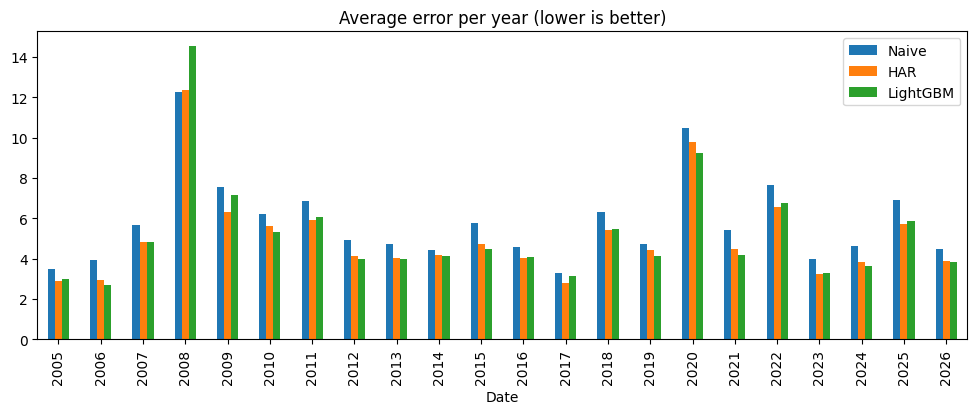

In [39]:
# Group the rows by calendar year, then compute each model's MAE inside every year
yearly = preds_pct.groupby(preds_pct.index.year).apply(
    lambda g: pd.Series({n: (g[n] - g["actual"]).abs().mean() for n in MODELS}))

# Draw it as a bar chart: one cluster of 3 bars per year
yearly.plot(kind="bar", figsize=(12, 4), title="Average error per year (lower is better)")
plt.show()

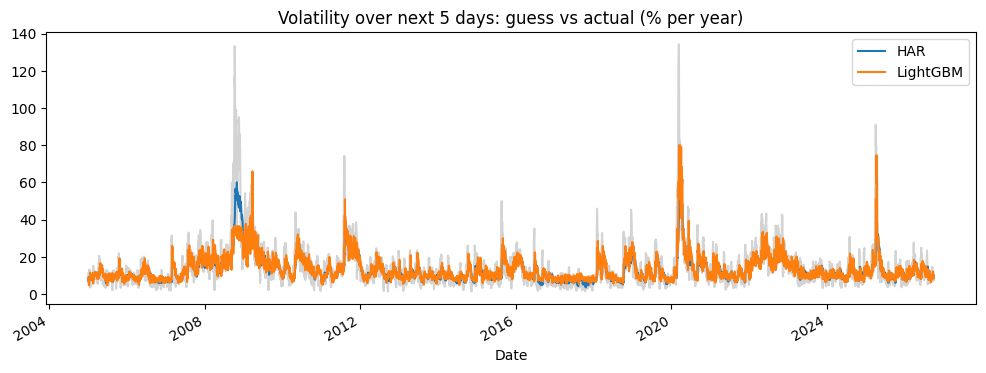

In [40]:
# Draw the real volatility as a light gray line (the "truth" in the background)
ax = preds_pct["actual"].plot(figsize=(12, 4), color="lightgray", label="actual")

# Draw HAR and LightGBM guesses on top of the same chart (ax=ax shares the drawing area)
preds_pct[["HAR", "LightGBM"]].plot(ax=ax)

ax.set_title("Volatility over next 5 days: guess vs actual (% per year)")
plt.show()

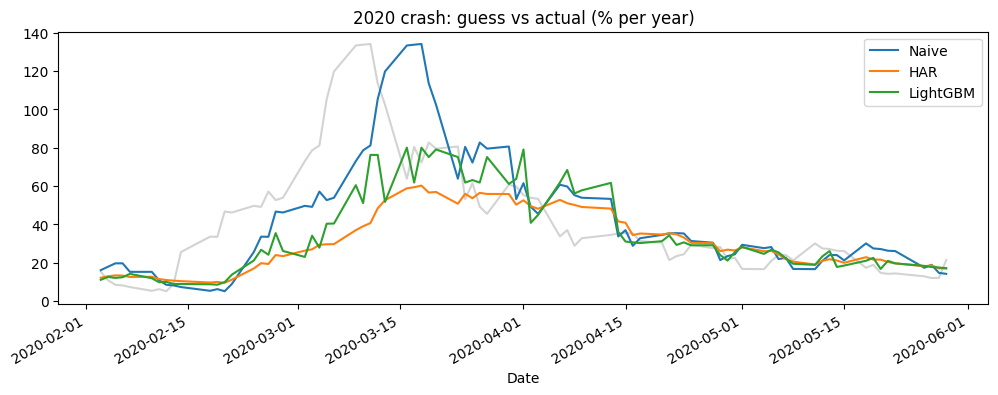

In [41]:
# Same chart, but only for February to May 2020 (.loc slices by date)
zoom = preds_pct.loc["2020-02":"2020-05"]

# Real volatility in gray, then the three model guesses on top (Naive included, for contrast)
ax = zoom["actual"].plot(figsize=(12, 4), color="lightgray", label="actual")
zoom[["Naive", "HAR", "LightGBM"]].plot(ax=ax)

ax.set_title("2020 crash: guess vs actual (% per year)")
plt.show()

In [42]:
# Remove 2008 and recompute each model's average error
# (a diagnostic only: we are NOT changing any model or setting)
no2008 = preds_pct[preds_pct.index.year != 2008]

for name in MODELS:
    # same MAE formula as before, but on the data without 2008
    err = (no2008[name] - no2008["actual"]).abs().mean()
    print(name, round(err, 2))

Naive 5.54
HAR 4.76
LightGBM 4.74


## 7. Conclusion
HAR had the smallest average error (5.11 points), followed by LightGBM (5.19) and Naive (5.85). Both models beat Naive, but LightGBM did not beat HAR: the gap of 0.08 points is tiny, so the simple formula was about as good as machine learning. The hardest years for all models were 2008 and 2020, with errors of about 9 to 14 points versus 3 to 4 in calm years, and LightGBM did worst in 2008. One thing I learned: <write your own sentence here>